In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df1=pd.read_csv(r"C:\Users\lenovo\Desktop\ASSIGNMENT DS\ToyotaCorolla - MLR.csv")

In [5]:
df1

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


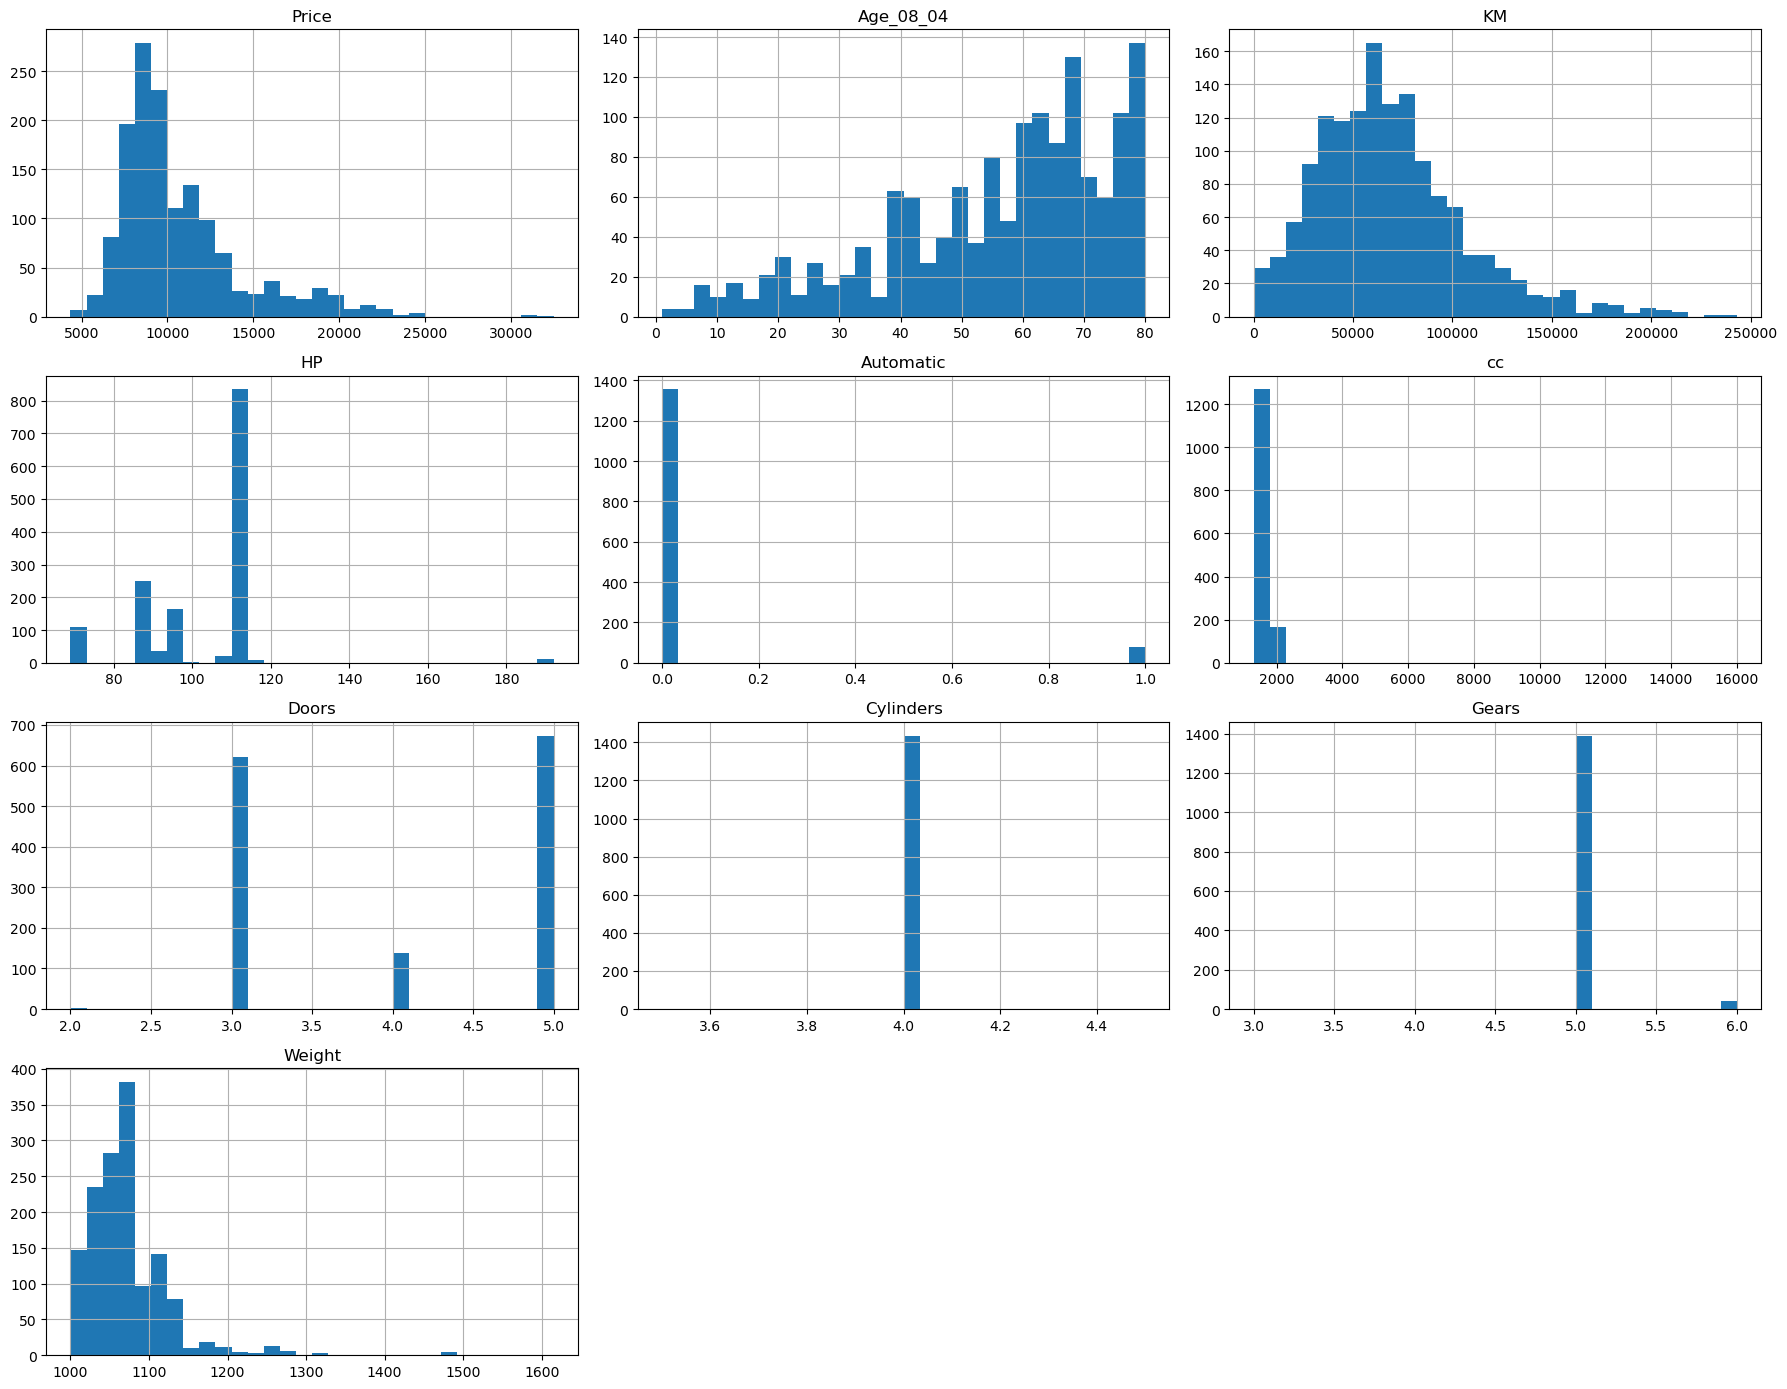

In [6]:
df1.hist(figsize=(18,14),bins=30)
plt.tight_layout()
plt.show()

In [7]:
df1.info()

df1.describe()

df1.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

C:\Users\lenovo\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


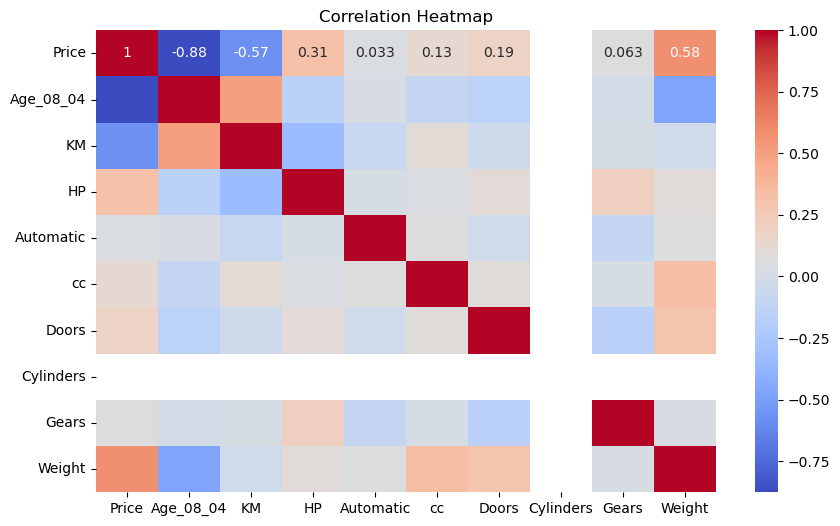

In [8]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

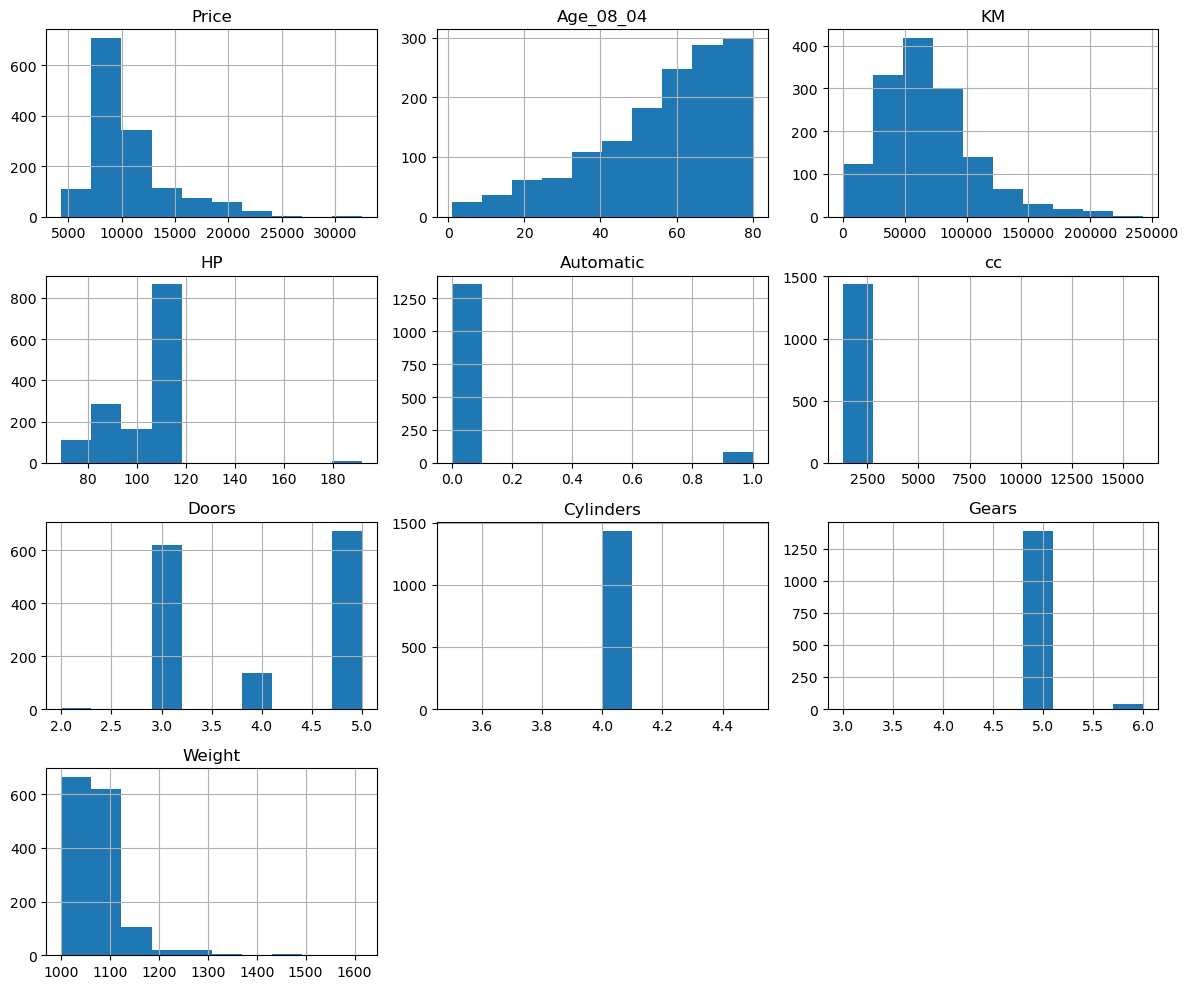

In [9]:
df1.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

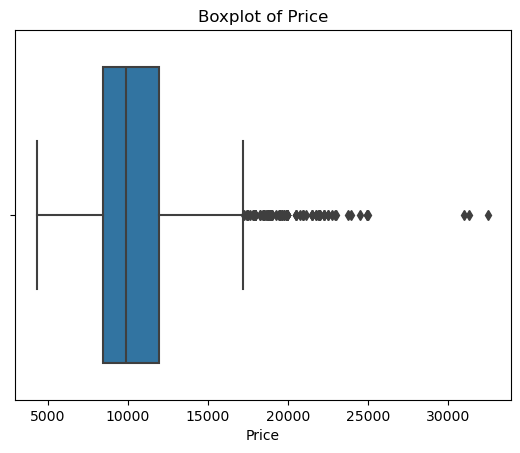

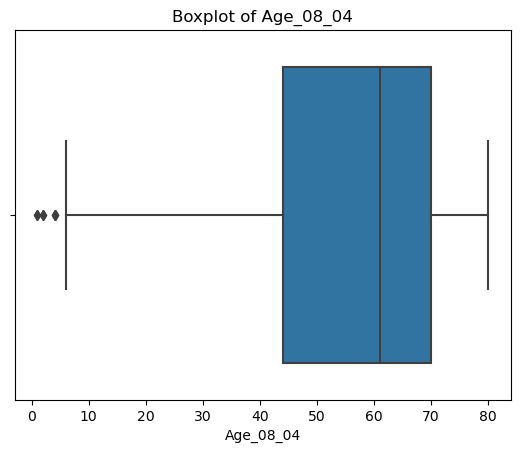

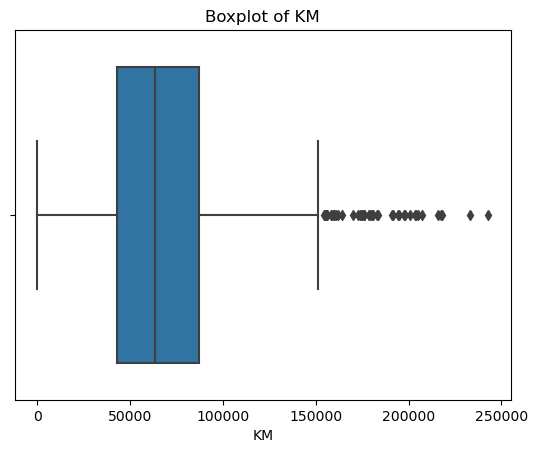

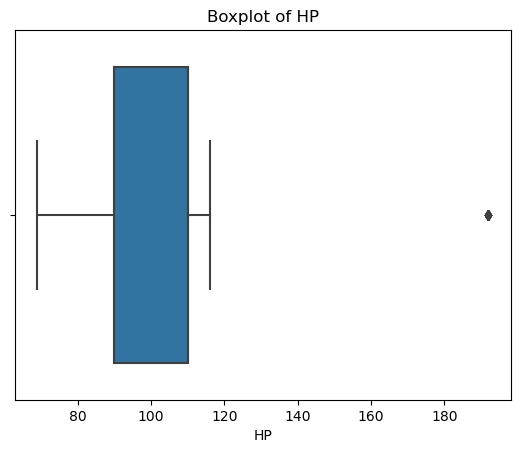

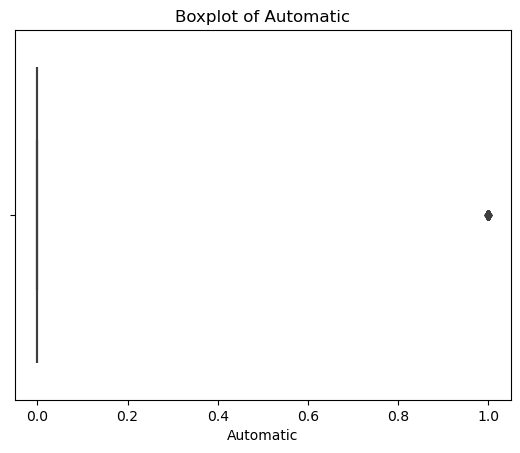

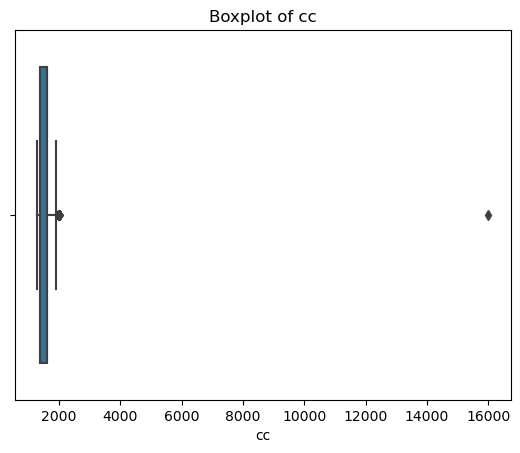

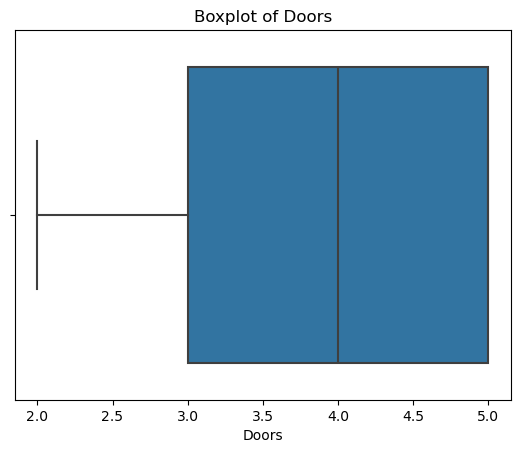

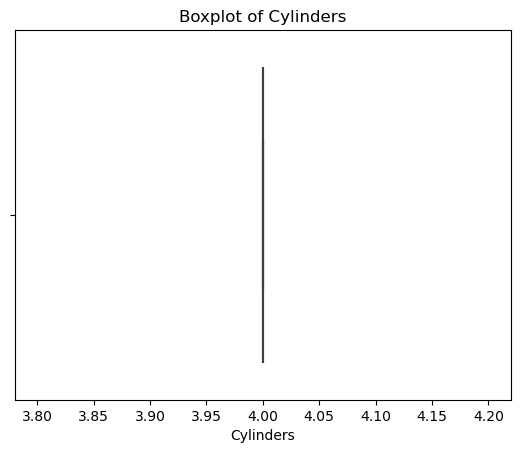

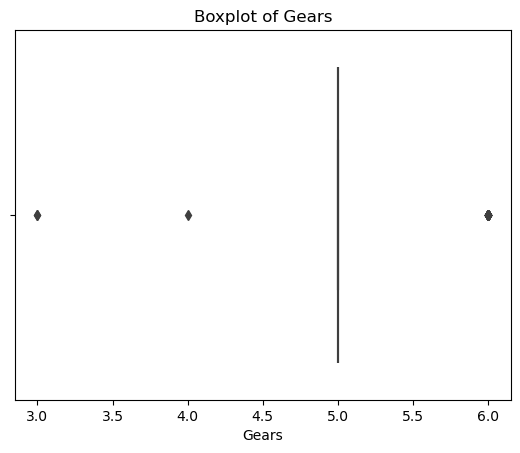

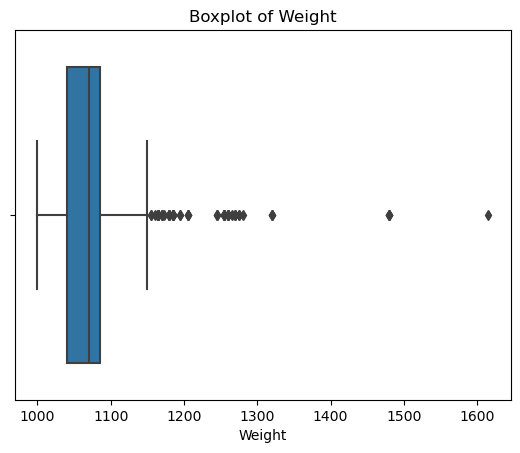

In [10]:
for col in df1.select_dtypes(include=np.number).columns:
    
    plt.figure()
    sns.boxplot(x=df1[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [11]:

x=df1.drop(["Price","Fuel_Type"],axis=1)
y=df1["Price"]

In [12]:
x.head()
y.head()

0    13500
1    13750
2    13950
3    14950
4    13750
Name: Price, dtype: int64

In [13]:

from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
x_trs=Scaler.fit_transform(x)
x_trs=pd.DataFrame(x_trs,columns=x.columns)
x_trs

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,-1.771966,-0.574695,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
1,-1.771966,0.117454,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
2,-1.718184,-0.715386,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
3,-1.610620,-0.547650,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
4,-1.395491,-0.801028,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.853577
...,...,...,...,...,...,...,...,...,...
1431,0.702015,-1.279939,-1.035138,-0.242893,-0.652594,-1.085139,0.0,-0.140425,-0.901883
1432,0.863362,-1.321120,-1.035138,-0.242893,-0.652594,-1.085139,0.0,-0.140425,-1.091915
1433,0.809579,-1.374036,-1.035138,-0.242893,-0.652594,-1.085139,0.0,-0.140425,-1.091915
1434,0.755797,-1.376703,-1.035138,-0.242893,-0.652594,-1.085139,0.0,-0.140425,-1.091915


In [14]:

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test,=train_test_split(x_trs,y,test_size=0.3,random_state=42)
X_train.shape

(1005, 9)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr=LinearRegression()
lr.fit(X_train,Y_train)
y_perdict_train=lr.predict(X_train)
R2_score_train=r2_score(Y_train,y_perdict_train)


In [16]:
print('Y predicted values:',y_perdict_train)
print('R2 score for train data:', R2_score_train)

Y predicted values: [12020.94525156  9850.08866432 11322.61938299 ...  7939.36342972
  8544.47360952  6535.53141306]
R2 score for train data: 0.8640529447897547


In [17]:
lr.fit(X_test,Y_test)
y_predict_test=lr.predict(X_test)
R2_score_test=r2_score(Y_test,y_predict_test)

In [18]:
print('Y predicted values:',y_predict_test)
print('R2 score for test data:', R2_score_test)

Y predicted values: [11342.89708468  8820.50082285  8998.87391608  8713.60404124
  9892.09505227  7533.65820491  8604.17976957  8146.53891215
 14069.9677443  13053.55211007  9164.76173691  9227.15903752
 12880.34380689 13210.42394059  9673.46112236  8272.03680152
 12413.99923581 17149.19136816  7191.78081452  8939.88144901
 12823.63195162 17881.00346945  7715.37264078 10526.1605949
  7312.34998688 15925.57690496  9767.25729964  7139.84367461
 15579.45464683 14508.00309286  7998.95004096  9693.43515223
  8255.89437179 10051.07507388 10221.76366515  7871.12749117
  8746.50292991  9910.79546269 16315.34762589  9318.16183193
  9794.71458446  9443.38710278  7589.48150658  5382.65468979
  6744.03385722 17049.87388959  9357.18188525 10514.2712523
  8758.43303919 13421.99477411 13064.57737704  6259.71126109
 14800.93427572 16224.98869427  5945.01709229  7453.38212063
 10339.35320799 10999.89471892 15920.60297586 19620.66197059
 12547.95466688  7705.50034337  7720.42140844 11114.24490019
 13331

In [26]:
X1=x_trs[["Age_08_04","KM","HP","Weight"]]
y=df1["Price"]

In [29]:
X1

,Age_08_04,KM,HP,Weight
0,-1.771966,-0.574695,-0.768042,1.758561
1,-1.771966,0.117454,-0.768042,1.758561
2,-1.718184,-0.715386,-0.768042,1.758561
3,-1.610620,-0.547650,-0.768042,1.758561
4,-1.395491,-0.801028,-0.768042,1.853577
...,...,...,...,...
1431,0.702015,-1.279939,-1.035138,-0.901883
1432,0.863362,-1.321120,-1.035138,-1.091915
1433,0.809579,-1.374036,-1.035138,-1.091915
1434,0.755797,-1.376703,-1.035138,-1.091915


In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test,=train_test_split(X1,y,test_size=0.3,random_state=42)
X_train.shape

(1005, 4)

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr=LinearRegression()
lr.fit(X_train,Y_train)
y_perdict_train=lr.predict(X_train)
R2_score_train=r2_score(Y_train,y_perdict_train)

In [32]:
print('Y predicted values:',y_perdict_train)
print('R2 score for train data:', R2_score_train)
lr.fit(X_test,Y_test)
y_predict_test=lr.predict(X_test)
R2_score_test=r2_score(Y_test,y_predict_test)
print('Y predicted values:',y_predict_test)
print('R2 score for test data:', R2_score_test)


Y predicted values: [12053.10534165  9844.5554077  11406.21022457 ...  8003.76922274
  8559.79276928  6602.65169073]
R2 score for train data: 0.8622963549556025
Y predicted values: [11296.96288211  8834.6136535   9185.13256338  8816.78101236
 10005.60304152  7590.62866412  8699.95522326  8197.71862615
 14187.20692738 13180.66975605  9212.18745431  9266.57021088
 13003.6309816  13160.58686617  9684.59847223  8110.011809
 12344.83201775 17220.74598575  7159.54824226  9057.13521289
 12899.47280523 17950.19791156  7740.7899721  10461.4389007
  7179.39190857 16006.62928128  9381.43505953  7112.38556483
 15483.34999571 14652.49260057  8016.93173457  9882.16539874
  8362.61902912 10084.64329882 10265.95048408  7882.21791584
  8850.07174034  9943.6423356  16216.99018628  9371.94877711
  9844.35649502  9487.18379236  7686.77035493  5120.93516789
  6567.00618585 17083.96865984  9387.61023037 10610.44660522
  8610.65593986 13564.02787146 13134.57290111  6092.58116612
 14672.40859198 16201.1738533

In [33]:
#model 2
X2=x_trs[["Age_08_04","KM","Weight"]]
y=df1["Price"]

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test,=train_test_split(X2,y,test_size=0.3,random_state=42)
X_train.shape

(1005, 3)

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr=LinearRegression()
lr.fit(X_train,Y_train)
y_perdict_train=lr.predict(X_train)
R2_score_train=r2_score(Y_train,y_perdict_train)

In [37]:
print('Y predicted values:',y_perdict_train)
print('R2 score for train data:', R2_score_train)
lr.fit(X_test,Y_test)
y_predict_test=lr.predict(X_test)
R2_score_test=r2_score(Y_test,y_predict_test)
print('Y predicted values:',y_predict_test)
print('R2 score for test data:', R2_score_test)


Y predicted values: [11756.64794588 10432.4323129  11293.34799333 ...  7779.94719208
  8998.20442571  6173.21270681]
R2 score for train data: 0.8492482967194258
Y predicted values: [11572.1099429   8529.79162008 10022.81777941  8560.72622556
  9814.67881341  7303.02916344  8371.78781963  8000.08356107
 13952.74740776 13039.91540108  8908.29447285  9051.82613251
 12808.46256507 13395.20256347  9356.75233865  8607.54879419
 12523.77760664 17695.98665931  6659.58622303  8851.20263051
 12645.94886772 17901.27064027  7493.97550827 10676.79330177
  7552.84359653 15948.21576129  9861.28870402  6631.19927055
 15813.10426626 14515.06131501  7695.76397222  9639.98066915
  8126.29881362  9794.11430894 10013.23034374  7579.06374663
  8507.1027415   9652.32052669 16528.06924045  8963.0532649
  9618.16248467  9243.72842452  7423.95533084  5281.25361025
  7028.88069427 16959.37442757  9094.77953178 10345.3778053
  9155.37306173 13474.60622499 12982.56147668  6598.57548082
 14890.27495993 16200.824962

In [39]:
#model 3
X3=x_trs[["Age_08_04","KM"]]
y=df1["Price"]


In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test,=train_test_split(X3,y,test_size=0.3,random_state=42)
X_train.shape

(1005, 2)

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr=LinearRegression()
lr.fit(X_train,Y_train)
y_perdict_train=lr.predict(X_train)
R2_score_train=r2_score(Y_train,y_perdict_train)

In [42]:
print('Y predicted values:',y_perdict_train)
print('R2 score for train data:', R2_score_train)
lr.fit(X_test,Y_test)
y_predict_test=lr.predict(X_test)
R2_score_test=r2_score(Y_test,y_predict_test)
print('Y predicted values:',y_predict_test)
print('R2 score for test data:', R2_score_test)


Y predicted values: [12035.86387358  9774.36017988 11488.32177107 ...  7067.64038252
  9757.62258403  6435.70272733]
R2 score for train data: 0.7960381944116199
Y predicted values: [12370.87990831  8521.56309891  9154.28194995  8111.6328391
  9356.76070202  6366.01705255  8691.81950578  7615.29407672
 14622.02443582 13091.43132413  8309.85063146  8876.32542004
 13077.79234066 14759.7153073   9620.16827114  9340.31062685
 13860.87423449 15597.44396059  6934.30470144  8309.03374115
 13742.92719552 18426.9406212   7051.04379059 11455.80261132
  8048.95431041 15748.81420027  9982.37873403  6838.35328412
 15800.64651598 15004.15968204  7638.46661919 10080.60587517
  7509.76497335 10137.70034379 10286.60642423  7338.84869233
  9004.08754044  9964.68032429 16746.48171125  9007.99704489
  9711.48638071  9303.7092096   6725.82767561  6313.23585567
  7500.88193276 16924.94483448  9279.14737622 10254.03340425
  9865.91968641 13463.49725318 13540.72848496  6825.15510064
 15020.19289189 15776.83054

In [44]:
#model 4
X4=x_trs[["Age_08_04","Weight"]]
y=df1["Price"]


In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test,=train_test_split(X4,y,test_size=0.3,random_state=42)
X_train.shape

(1005, 2)

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr=LinearRegression()
lr.fit(X_train,Y_train)
y_perdict_train=lr.predict(X_train)
R2_score_train=r2_score(Y_train,y_perdict_train)

In [50]:
print('Y predicted values:',y_perdict_train)
print('R2 score for train data:', R2_score_train)
lr.fit(X_test,Y_test)
y_predict_test=lr.predict(X_test)
R2_score_test=r2_score(Y_test,y_predict_test)
print('Y predicted values:',y_predict_test)
print('R2 score for test data:', R2_score_test)


Y predicted values: [12113.39679174 11779.24975225 10557.81807041 ...  7106.66966954
  8930.39042661  6603.72721231]
R2 score for train data: 0.8056292628443017
Y predicted values: [10883.41857899  8563.46939568 11228.16303127  8335.20267677
  9346.10628867  7175.22808512  8481.16682368  7241.99649287
 14315.21494332 12686.27958244  9117.83956976  8563.46939568
 12762.36848874 13212.68826086  9650.46191389  8395.75741882
 12591.54967903 18874.39265291  7707.85042924  8335.20267677
 12829.13689649 17661.60190278  7010.62294111 10262.27999716
  8091.40179361 15569.91943838 10119.42268311  7552.56578378
 15646.00834469 14315.21494332  7707.85042924  9333.67895727
  7714.06409494  9881.83546565  9881.83546565  7476.47687748
  8712.54037544  9726.55082019 16577.71621743  9811.96022505
  9260.69688382  8950.1275929   7092.92551311  6842.91096424
  6842.91096424 17205.06846497  9105.41223836 10433.09880688
  8706.32670974 12841.5642279  12600.87017758  6066.48773696
 15335.43905377 15493.8305

In [53]:

#Step 7: Apply ShuffleSplit Cross-Validation
from sklearn.model_selection import ShuffleSplit,cross_validate
# cross_val_score
shuffle_split = ShuffleSplit(n_splits=500, test_size=0.2, random_state=42)
cv_scores = cross_validate(lr, x_trs, y, cv=shuffle_split, scoring='r2',return_train_score=True)

# Extract train and test scores
train_scores = cv_scores['train_score']
test_scores = cv_scores['test_score']

# Show individual scores and their means
print("cross validation: training score:" , np.round(train_scores.mean(),2))
print("cross validation: test score:" , np.round(test_scores.mean(),2))

cross validation: training score: 0.86
cross validation: test score: 0.83


In [56]:
 #Step 8: Apply LassoCV to find the best alpha
from sklearn.linear_model import LassoCV
from sklearn.model_selection import ShuffleSplit
import numpy as np

# Define the ShuffleSplit cross-validation strategy
shuffle_split_lassocv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)

# Define the LassoCV model
# The `alphas` parameter can be left as None to let LassoCV automatically determine the path
lassocv_model = LassoCV(cv=shuffle_split_lassocv, random_state=42)

# Fit the model
lassocv_model.fit(x_trs, y)

# Get the best alpha and the corresponding mean squared error
best_alpha_lassocv = lassocv_model.alpha_
mse_path = lassocv_model.mse_path_
mean_mse = mse_path.mean(axis=1)
best_mse = mean_mse[lassocv_model.alphas_ == best_alpha_lassocv][0]

print("\nLassoCV Results:")
print("Best alpha found:", best_alpha_lassocv)
# You can also access the mean squared error for the best alpha
print("Mean squared error for best alpha:", best_mse)


LassoCV Results:
Best alpha found: 63.85855791717686
Mean squared error for best alpha: 1844891.842923499


In [57]:
# Step 11: Fit Lasso model with best alpha and count zero/non-zero coefficients
from sklearn.linear_model import Lasso

final_lasso_model = Lasso(alpha=best_alpha_lassocv)
final_lasso_model.fit(x_trs, y) # Fit on the entire dataset for coefficient analysis

# Get the coefficients
lasso_coefficients = final_lasso_model.coef_

# Count zero and non-zero coefficients
zero_coefficients = np.sum(lasso_coefficients == 0)
non_zero_coefficients = np.sum(lasso_coefficients != 0)

print("\nAnalysis of Lasso Coefficients (with best alpha):")
print("Number of zero coefficients:", zero_coefficients)
print("Number of non-zero coefficients:", non_zero_coefficients)


Analysis of Lasso Coefficients (with best alpha):
Number of zero coefficients: 3
Number of non-zero coefficients: 6


In [ ]:
#Normilsation Scales data to a fixed range, usually 0 to 1 and  Standarizing Transforms data to have mean = 0 and standard deviation = 1.
#Prevent features with larger values from dominating the model.
#Improve model convergence during training.
#Increase accuracy for algorithms that rely on distances or gradients.
#Make coefficients more comparable in linear models.




#Multicollinearity occurs when two or more independent variables are highly correlated, making it difficult to estimate their individual effects.

#Remove Highly Correlated Features
#Variance Inflation Factor (VIF)
#Feature Selection
#Principal Component Analysis (PCA)
#Regularization Techniques
#Collect More Data












                                                                                                                                   